**The Objective of this notebook to give step by step mechanism of the Gottesman-Knill theorem and guide to what the rules include**

Mostly the topics include

- Basic Rules of The stabilizer formalism
- Tableau Representation( with and without destabilizers)
- Measurement Effects on the evolution of tableau
  - Non-determinant
  - Determinant measurement Outcome
- Phase evolution
- Rundown On CHP Simulator (Aaronson-Gottesman Stabilizer Simulation)

This notebook requires prior knowledge of stabilizers and clifford gates 

# Gottesman- Knill Theorem 
 **(Gottesman-Knill): Given a circuit starting from an initial stabilizer state, followed by a
sequence of Clifford group operations and Pauli measurements, which may depend on classical computations
performed on previous measurement results, there is an efficient classical simulation of the circuit.**

*In other Words it says that a stabilizer circuit—that is, a quantum circuit consisting solely of CNOT, Hadamard, and phase gates—can be simulated efficiently on a classical computer*

## Basic rules of stabilizer formalism 

### 1. Initialization & tableau representation
For a given $n$ qubit circuit, The initial state is $$|00\ldots0\rangle$$
The first step is to find a generating set for its stabilizer group.

Since $|0\rangle$ is a $+1$ eigenstate of $Z$, a valid generating set is:

$$
ZIII\ldots I \\
IZII\ldots I \\
IIZI\ldots I \\
\vdots \\
IIII\ldots Z
$$

Stabilizer group contains $II\ldots I$, but we won’t put that into the generating set

Since Its a $n$ Qubit Circuit we need
- An $n \times n$ binary **X matrix**
- An $n \times n$ binary **Z matrix**
- (Optionally) $n$ sign bits

*The two matrices can be combined entrywise to produce an {I,X,Y,Z} matrix*

For example, the tableau for $|0000\rangle$ is:
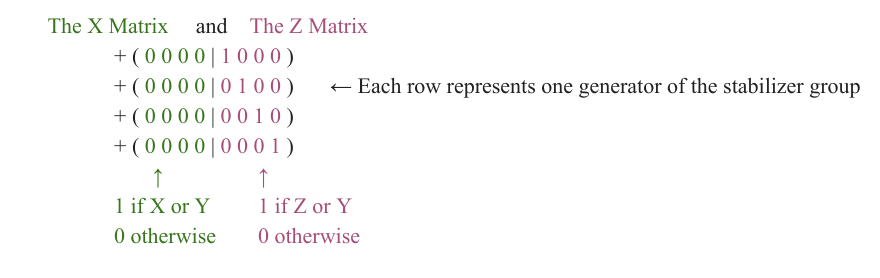
This represents the generators:

$$
\{ ZIII, IZII, IIZI, IIIZ \}.
$$

### 2. Tableau Update Rules 
We now describe how to update the tableau under Clifford gates.

#### 2.1 To apply Hadamard on qubit i

Swap $i$'th column of the X matrix with $i$'th column of the Z matrix.

Intuition: Hadamard swaps the $X$ and $Z$ bases.

---

#### 2.2 To apply Phase (P) on qubit i

Bitwise XOR column $i$ of the X matrix into column $i$ of the Z matrix.

That is:

$$
Z_i \leftarrow Z_i \oplus X_i
$$

Notice that $P$ does nothing to the initial $|00\ldots0\rangle$ tableau.

---

#### 2.3 To apply CNOT from qubit i(control) to qubit j(target)

1. XOR column $i$ of X into column $j$ of X:

$$
X_j \leftarrow X_j \oplus X_i
$$

2. XOR column $j$ of Z into column $i$ of Z:

$$
Z_i \leftarrow Z_i \oplus Z_j
$$

This matches the propagation rules:

- $X$ spreads forward (control → target)
- $Z$ spreads backward (target → control)

### 3. Measurement Rule

When measuring qubit $i$ in the $\{|0\rangle, |1\rangle\}$ basis:

- The outcome is **deterministic** (only one outcome is possible)  
  if and only if column $i$ of the X matrix is all zeros.

Otherwise, the outcome is random.

(Full update rules for the random case exist but are more involved.)



#### A Structural Insight

The number of computational basis states with nonzero amplitude is: $2^k$

where $k = \text{rank}(X)$.

For the initial state, $\text{rank}(X)=0$,  
so the state contains only one basis vector: $|0000\rangle$.

### 4. Example Evolution

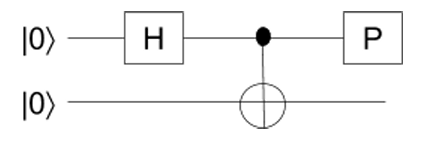

Start with 2 qubits:

$$
\begin{pmatrix}
0 & 0 \; | \; 1 & 0 \\
0 & 0 \; | \; 0 & 1
\end{pmatrix}
$$

This corresponds to generators $\{ ZI, IZ \}$.



#### After Hadamard on qubit 1

Swap first X and Z columns:

$$
\begin{pmatrix}
1 & 0 \; | \; 0 & 0 \\
0 & 0 \; | \; 0 & 1
\end{pmatrix}
$$

This corresponds to generators $\{ XI, IZ \}$,  
which stabilize $|0\rangle \otimes |+\rangle$.


#### After CNOT (1 → 2)

- XOR X column 1 into column 2
- XOR Z column 2 into column 1

Result:

$$
\begin{pmatrix}
1 & 1 \; | \; 0 & 0 \\
0 & 0 \; | \; 1 & 1
\end{pmatrix}
$$

This corresponds to generators $\{ XX, ZZ \}$ —  
the Bell pair stabilizers.



#### After Phase on qubit 1

XOR column 1 of X into column 1 of Z:

$$
\begin{pmatrix}
1 & 1 \; | \; 1 & 0 \\
0 & 0 \; | \; 1 & 1
\end{pmatrix}
$$

This corresponds to the state:

$$
\frac{|00\rangle + i|11\rangle}{\sqrt{2}}.
$$



### Few QEC Codes Encoding's Stabilizers 

#### 3 Qubit Bit Flip Repitition code encoding 

Insert stabilizer matrix evolution flowchart after Every gate application

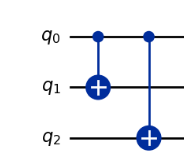
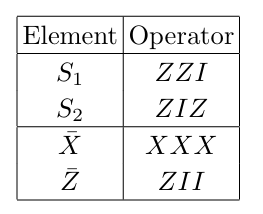


Stabilizer generators:
$\{ZII,IZI,IIZ\}$



#### 3 Qubit Phase Flip Repitition code encoding 

Insert stabilizer matrix evolution flowchart after Every gate application

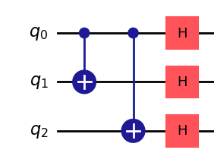 
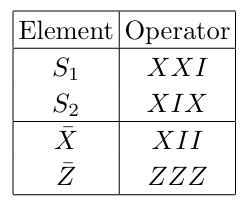

#### 9 Qubit Shor code encoding 

Insert stabilizer matrix evolution flowchart after Every gate application


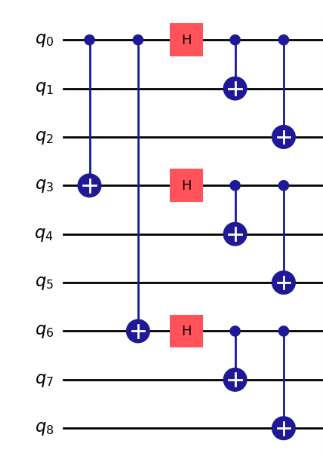
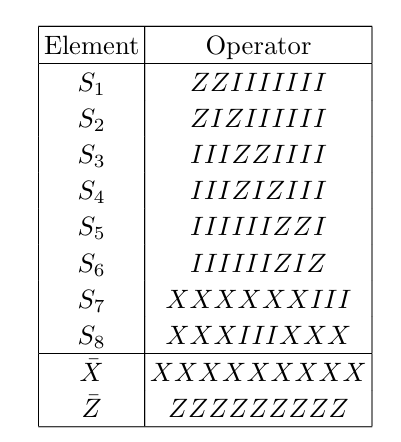

# Standard Tableau Represenation

Few Things we missed in before explanation are 
- Destabilizers
- Phase Evolution column
- What happens when Measurement is involved 
   - Determinant outcome
   - Non-determinant outcome
*To implement the full Gottesman–Knill algorithm,we must include all three.*

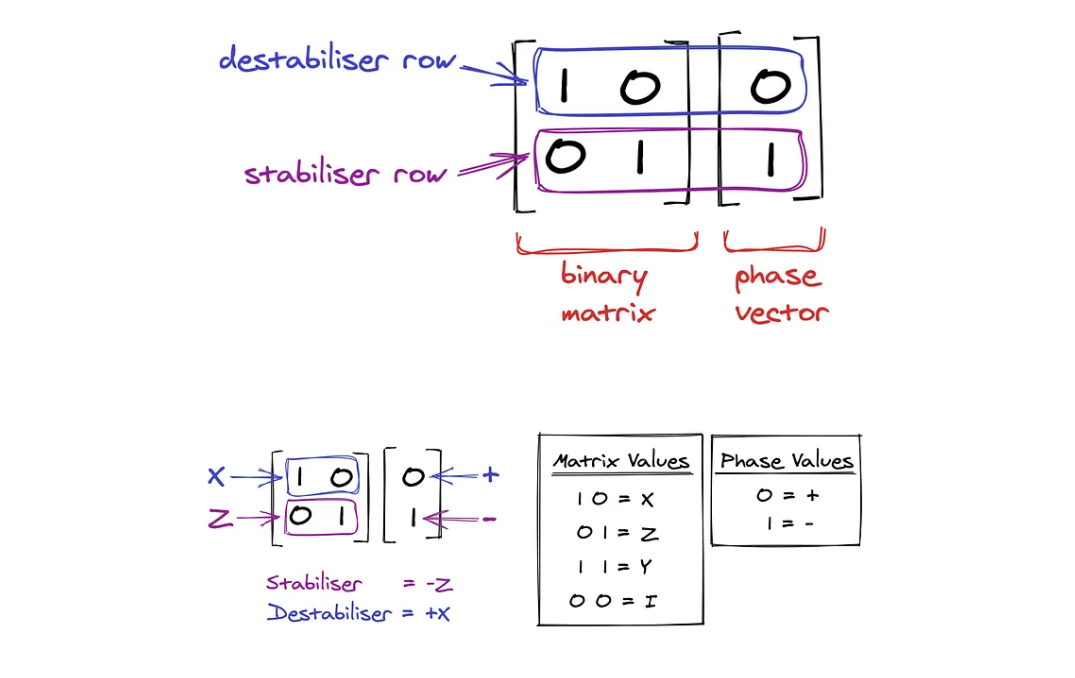

### 1. Initailization matrix

For an $n$-qubit system, we maintain:

- An $n \times n$ binary **X matrix**
- An $n \times n$ binary **Z matrix**
- $n$ phase entries

That describes the stabilizers.

However, the standard tableau also includes **destabilizers**.

So the full tableau has:

- $2n$ rows  
- $2n$ Pauli columns (X block | Z block)  
- 1 phase column  

So the total size is:

$$
2n \times (2n + 1)
$$

We can think of it as:

```
| X block (n columns) | Z block (n columns) | r | 
```

Rows:
- 1 to n → Destabilizers  (*Top n rows*)
- n+1 to 2n → Stabilizers (*Bottom n rows*)

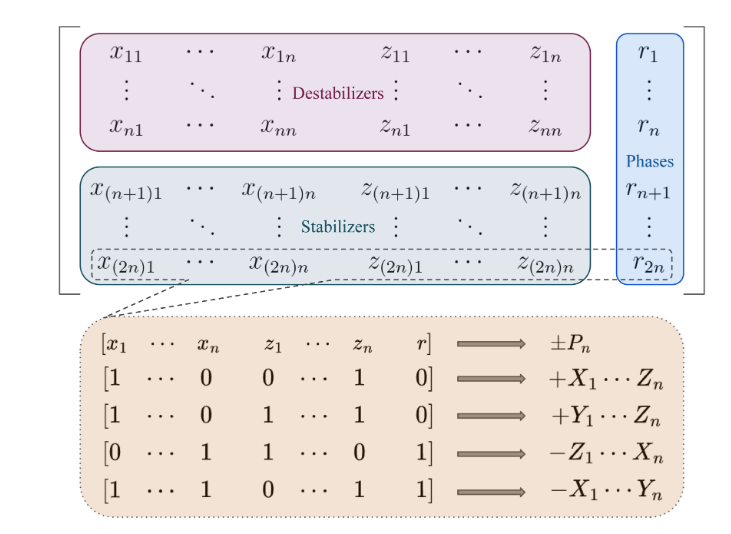

#### Destabilizers
Initialization for $|000\ldots0\rangle$
For the initial state:

$$
|000\ldots0\rangle
$$

The stabilizer generators are:

$$
\{ Z_1, Z_2, \ldots, Z_n \}
$$

For example, for $n=3$:

$$
\{ ZII, IZI, IIZ \}
$$


Destabilizers are chosen such that:

- Each destabilizer anticommutes with exactly one stabilizer
- It commutes with all others
- Every Stabilizer has its corresponding destabilizer 

For $|000\rangle$, they are:

$$
\{ XII, IXI, IIX \}
$$

#### Phase Representation

The phase column $r$ tracks powers of $i$.

Possible values:

| r | Phase |
|---|-------|
| 0 | $+1$  |
| 1 | $+i$  |
| 2 | $-1$  |
| 3 | $-i$  |

All arithmetic on $r$ is modulo 4.

Initially, for $|000\ldots0\rangle$, all rows have:

$$
r = 0
$$

#### Why Do Phases Change?

Pauli matrices do not always multiply cleanly.

Examples:

$$
XZ = -ZX
$$

$$
XY = iZ
$$

$$
YZ = iX
$$

So when:

- Rows are multiplied,
- Generators are updated,
- Measurement replaces stabilizers,

we may introduce factors of:

- $-1$
- $\pm i$

The tableau must track these changes via the phase column.

Without it, measurement predictions would be incorrect.



#### Why Destabilizers Are Necessary

If we only tracked stabilizers:

- Clifford updates would still work,
- But measurement updates would become inefficient.

Destabilizers provide:

- A full symplectic basis
- Efficient row replacement during measurement
- Proper tracking of anticommutation relations

Each destabilizer row anticommutes with exactly one stabilizer row.

This pairing is essential for the full algorithm.



#### Full Initial Tableau (n = 3)

For $|000\rangle$, the full tableau corresponds to:

$$
\begin{pmatrix}
1 & 0 & 0 \; | \; 0 & 0 & 0 \; | \; 0 \\
0 & 1 & 0 \; | \; 0 & 0 & 0 \; | \; 0 \\
0 & 0 & 1 \; | \; 0 & 0 & 0 \; | \; 0 \\
\hline
0 & 0 & 0 \; | \; 1 & 0 & 0 \; | \; 0 \\
0 & 0 & 0 \; | \; 0 & 1 & 0 \; | \; 0 \\
0 & 0 & 0 \; | \; 0 & 0 & 1 \; | \; 0
\end{pmatrix}
$$

Top 3 rows → Destabilizers  
Bottom 3 rows → Stabilizers  
Last column → Phase entries  

Initially, all phase entries are zero indicating +1 phase


Destabilizers:
$$
\{ XII, IXI, IIX \}
$$

Stabilizers:
$$
\{ ZII, IZI, IIZ \}
$$

All phase entries:
$$
r = 0
$$

This is the starting point of the full Aaronson–Gottesman stabilizer simulation algorithm.


## 2. Tableau Update rules
*the same rules applied on both the destabilizer and stabilizer rows*

### 2.1 Gate evolution
How application of each Clifford gate changes the matrix

1.  **Hadamard on qubit i**

    - Swap $i$'th column of the X matrix with $i$'th column of the Z matrix.
    - Intuition: Hadamard swaps the $X$ and $Z$ bases.


2.  **Phase on qubit i**

    - Bitwise XOR column $i$ of the X matrix into column $i$ of the Z matrix.
    - That is: $Z_i \leftarrow Z_i \oplus X_i$

    Notice that $P$ does nothing to the initial $|00\ldots0\rangle$ tableau. (becuase Phase gate z stabilizes it)

3. **To apply CNOT from qubit i(control) to qubit j(target)**
    - X-matrix :XOR column $i$ of X into column $j$ of X:  $$X_j \leftarrow X_j \oplus X_i$$
    - Z-matrix: XOR column $j$ of Z into column $i$ of Z:  $$Z_i \leftarrow Z_i \oplus Z_j$$
    - This matches the propagation rules:
      - $X$ spreads forward (control → target)
      - $Z$ spreads backward (target → control)

### 2.2 Phase Evolution

Each row of the tableau represents a Pauli operator of the form:

$$
P = i^{\,r[i]} \; X^{\mathbf{x}} Z^{\mathbf{z}}
$$

where:

- $\mathbf{x}, \mathbf{z} \in \mathbb{F}_2^n$
- $r[i] \in \{0,1,2,3\}$

The value $r[i]$ is the **exponent of $i$**.

So the phase of the row is:

$$
i^{\,r[i]}
$$



#### Phase Encoding

| r[i] | Phase |
|------|--------|
| 0 | $i^0 = +1$ |
| 1 | $i^1 = +i$ |
| 2 | $i^2 = -1$ |
| 3 | $i^3 = -i$ |

All arithmetic on $r[i]$ is performed modulo 4.



#### Fundamental Principle

Clifford conjugation never produces $\pm i$ phases.

For any Pauli $P$ and Clifford $U$:

$$
U P U^\dagger = \pm P'
$$

Only $\pm 1$ can appear.

The $\pm i$ phases arise **only when two Pauli operators are multiplied together** (e.g., during row multiplication).


#### Universal Source of Phase

All phase changes ultimately come from the Pauli multiplication rules:

Two Pauli operators anti-commute if they differ and are both non-identity on the same qubit.

#### Single-Qubit Multiplication Table

| Multiply        | Result    |
|-----------------|-----------|
| $XZ$ | $  iY $ |
| $ZX$ | $ -iY $ |
| $XY$ | $  iZ $ |
| $YX$ | $ -iZ $ |
| $YZ$ | $  iX $ |
| $ZY$ | $ -iX $ |

Every phase update in the simulator enforces consistency with this table.

---



#### Phase Evolution Under Each Gate



#### 1️⃣ Hadamard Gate (H)

**Mathematically:** $HXH = Z$ , $HZH = X$, $HYH = -Y$

**Binary Update:** If Hadamard is applied on qubit $i$:
> Swap the X and Z columns corresponding to qubit $i$.

**Phase Update**

- **After the swap:** If  $X_i = 1 \quad \text{and} \quad Z_i = 1$
then the operator is $Y$ on that qubit.

- Since: $H Y H = -Y$
- The Phase updates to $-1$
- $ r[i] \leftarrow (r[i] + 2) \bmod 4$

Adding 2 corresponds to multiplying by $-1$.

#### example H on qubit 0
- Initial matrix

$$
\begin{pmatrix}
1 & 0 \; | \; 1 & 1\; | \;  +1\\
\hline
0 & 1 \; | \; 1 & 0 \; | \; +1 \\
\end{pmatrix}
$$

- after H

  
$$
\begin{pmatrix}
1 & 0 \; | \; 1 & 1\; | \;  -1\\
\hline
1 & 1 \; | \; 0 & 0 \; | \; +1 \\
\end{pmatrix}
$$

- we need to check each row in column 0 of x matriz and x matriz 

- first rwo $x[0][0]=z[0][0] = 1$ after H so $r =-1$
- second row $x[1][0]=1$ and $z[1][0] = 0$ so r stays same $r=+1$

---

#### 2️⃣ Phase Gate (P)

**Mathematically:** $P X P^\dagger = Y$,  $P Y P^\dagger = -X$, $P Z P^\dagger = Z$

**Binary Update:** If Phase is applied on qubit $i$:
$Z_i \leftarrow Z_i \oplus X_i$ 
In words:
> XOR the X column into the Z column for that qubit.

**Phase Update**
- **Before applying the p gate**: If $ X_i = 1 \quad \text{and} \quad Z_i = 1$
then the operator is $Y$.
- Since:$P Y P^\dagger = -X$
- Phase changes after the gate application to ($-1$)
$r[i] \leftarrow (r[i] + 2) \bmod 4$

Then perform:$Z_i \leftarrow Z_i \oplus X_i$
Again:
- Only $\pm 1$ phase
- Never $\pm i$

#### example -P on qubit 0
- Initial matrix 
$$
\begin{pmatrix}
1 & 0 \; | \; 1 & 1\; | \;  +1\\
\hline
0 & 1 \; | \; 1 & 0 \; | \; +1 \\
\end{pmatrix}
$$

- after P
$$
\begin{pmatrix}
1 & 0 \; | \; 0 & 1\; | \;  -1\\
\hline
0 & 1 \; | \; 1 & 0 \; | \; +1 \\
\end{pmatrix}
$$

- Before $P$ we check each row of coulmn 0 on both x-matrix and z-matrix 
where $x=z=1$ there after $p$ we give phase sign 

---
#### 3️⃣ CNOT Gate

Let:
- Control qubit = $c$
- Target qubit = $t$

**Mathematically:** $X_c \rightarrow X_c X_t$ , $Z_t \rightarrow Z_c Z_t$

All other Paulis remain unchanged.

**Binary Update Rule :** For every row:
$X_t \leftarrow X_t \oplus X_c$, $Z_c \leftarrow Z_c \oplus Z_t$
 - X on control spreads to target
 - Z on traget spreads to control
 - During Pure X and Z cases phase never happens
   
**Phase Update rule**

**After the application of CNOT gate: A sign flip occurs exactly when:**

$$x_c = 1,
\quad
z_t = 1,
\quad
x_t = z_c
$$

In other words 
$$
 x_c \oplus z_t  \oplus (x_t \oplus z_c \oplus 1)
$$

If this condition is satisfied: Then Sign flips to $-1$

$$
r[i] \leftarrow (r[i] + 2) \bmod 4
$$

Otherwise, no phase change.

#### Example-CNOT

1. **Before CNOT**

$$
x_c=1,\; x_t=0,\; z_c=0,\; z_t=1
$$

Matrix form:

(1 0 | 0 1)

This represents:

$$
X_c Z_t
$$

2. **Step 1 — Bit Update**

$$
x_t = 0 \oplus 1 = 1
$$

$$
z_c = 0 \oplus 1 = 1
$$

New row:

(1 1 | 1 1)


3. **Step 2 — Phase Check**

$$
x_c=1,\; z_t=1,\; x_t=1,\; z_c=1
$$

Condition:

$$
x_c \land z_t \land (x_t = z_c)
$$

True → phase flips:

$$
r \leftarrow r + 2
$$

4.**Why the Sign Appears**

CNOT transformed:

$$
X_c Z_t
$$

into:

$$
X_c X_t Z_c Z_t
$$

Reordering per qubit:

$$
X_c Z_c = -iY_c
$$

$$
X_t Z_t = -iY_t
$$

Combined:

$$
(-i)(-i) = -1
$$

So:

$$
CNOT(X_c Z_t)CNOT^\dagger = -Y_c Y_t
$$

That $-1$ is exactly what the phase rule captures.

#### 4️⃣ Row Multiplication

This is the only place where $\pm i$ can appear.

When multiplying two rows:

$$
P_k P_i
$$

The phase update is:

$$
r[i] = r_k + r_i + \text{(Pauli multiplication phase)} \pmod{4}
$$

This implements exact Pauli multiplication using the universal multiplication table.

---
#### 5. Measurement and Phase

When measuring qubit $i$ in the computational basis:

- If the measurement is deterministic, the stabilizer already fixes the eigenvalue.
- If the measurement is non-deterministic, the outcome is randomly $\pm 1$.

In the latter case, the phase $r$ of the replacing stabilizer generator is set to:

- $0$ for eigenvalue $+1$
- $2$ for eigenvalue $-1$

This corresponds to assigning a $\pm 1$ phase.

#### Final Structural Picture

The tableau evolves via:

1. Linear XOR updates on X/Z bits.
2. Modular updates on phase exponent $r$.

The X/Z blocks encode symplectic structure.  
The phase column ensures exact Pauli group multiplication.

Clifford gates produce only $\pm 1$.  
Row multiplication can produce $\pm i$.

### 2.3 Measurement

#### Measurement of Qubit $i$ in the Stabilizer Tableau 

We measure qubit $i$ in the Z-basis.

The measurement operator is:
$$
M = I \cdots I \, Z_i \, I \cdots I
$$

**In the tableau**

- Top n rows $\leftarrow$ **destabilizers**
- Bottom n rows $\leftarrow$ **stabilizers**

**Measurement checks the stabilizer rows only.**

The measurement outcome is of two types 
1. **Deterministic outcome:** There is one possible outcome 

   example : ${|00\rangle}$
   
3. **Non-Deterministic outcome:** The outcome is probablistic

   example : $\frac{|00\rangle + |11\rangle}{\sqrt{2}}$

   This superpostion state collapses to random after measurement  
   

#### 2.3.1 Deterministic Outcome

When measuring the $i$-th qubit, we look at the **$i$-th column** of the **X matrix** (stabilizer rows only).

The measurement is deterministic **if and only if**:

> All entries in column $i$ of the stabilizer X-matrix are 0.

That means:

- No stabilizer contains $X$ or $Y$ on qubit $i$.
- All stabilizers commute with $Z_i$.
- The state is already an eigenstate of $Z_i$.

---

### What happens to the tableau?

- The stabilizer group does **not** change.
- No row replacement occurs.
- The measurement outcome is determined by existing stabilizers.
- The phase (±1 eigenvalue) is computed from the stabilizer structure.

---

### Example

Consider the state:

$$
|00\rangle
$$

The tableau (destabilizers on top, stabilizers below) is:

$$
\begin{pmatrix}
1 & 0 \; | \; 0 & 0 \; | \; 0 \\
0 & 1 \; | \; 0 & 0 \; | \; 0 \\
\hline
0 & 0 \; | \; 1 & 0 \; | \; 0 \\
0 & 0 \; | \; 0 & 1 \; | \; 0 \\
\end{pmatrix}
$$

If we measure **qubit 2**, we inspect column 2 of the stabilizer X-matrix.

Since all entries in that column are 0,

the measurement is **deterministic**.

The outcome is fixed (always 0), and the tableau remains unchanged.




#### Number of Basis States

The number of computational basis states with nonzero amplitudes is:

$$
2^k
$$

where $k$ is the rank of the **X matrix** (stabilizer portion).

In the above example:

$$
\text{rank}(X) = 0
$$

So the state contains only a single basis state:

$$
|00\rangle
$$


#### 2.3.2 Non-deterministic outcome

The measurement is non-deterministic **if**:

At least one stabilizer has $X=1$ in column $i$.

That means:

- At least one stabilizer anti-commutes with $Z_i$.
- The state is in superposition relative to the Z-basis on qubit $i$.
- Measurement will collapse the state.

---
**Tableau gets updated during non-determinstic outcome**

**The rule :**


**1. Check commutation of each existing stabilizer $S_j$  with our measurement observable $Z_i$**
   -  Suppose one or more stabilizers anti-commute with $Z_i$.

**2. Replace the first encountered anti commuting stabilizer($S_p$) with $Z_i$**
$$
S_p := Z_i
$$

Now $Z_i$ becomes a stabilizer generator.

**3. To preserve the simplectic pairing move this Sp to Destabilizer block**
    
$$
D_p := \text{old } S_p
$$

**4. Assign Random Phase**

The new stabilizer $Z_i$ receives eigenvalue:

- $+1$  → phase $r=0$
- $-1$  → phase $r=2$

This is chosen randomly.

Only ±1 occurs — never ±i.

This represents quantum collapse.

**5. For the Remaining anti-commuting stabilizer**
   
If there are other stabilizers (or destabilizers) that also had $X = 1$ in column $i$,

we must remove their anti-commutation with $Z_i$.

For every other row $R \neq p$ such that:

$$
X_i(R) = 1
$$

we perform:

$$
R \leftarrow R \cdot D_p
$$

where $D_p$ is the moved row (the old stabilizer).

This removes the $X$ in that column via XOR.

After this step:

- All stabilizers commute with $Z_i$.
- The symplectic structure is preserved.
- Stabilizer rank remains $n$.

---

**Important Clarification**

If there were multiple anti-commuting stabilizers:

- We replace only **one** of them.
- The others are modified (not replaced).
- They remain stabilizers.
- They are multiplied by the moved row to restore commutation.

---

####  Conceptual Effect

Each non-deterministic measurement:

- Destroys exactly one independent X-type stabilizer.
- Reduces the superposition dimension by a factor of 2.
- Inserts a classical constraint: $Z_i = \pm 1$

---

#### Summary

When measuring qubit $i$:

**Deterministic**
- X column in stabilizers is all zero.
- No change to stabilizers.
- Outcome is fixed.

**Non-Deterministic**
1. Find the first stabilizer with $X = 1$ in column $i$.
2. Move it to the destabilizer block.
3. Replace it with $Z_i$.
4. Assign a random ±1 phase.
5. Multiply all other rows with $X = 1$ in column $i$ by the moved row.

   

# Examples
Full length Example evolutions to make the explanations sense


## 1.Ex-1: Determinant outcome 



# Example  Qiskit Implementations  


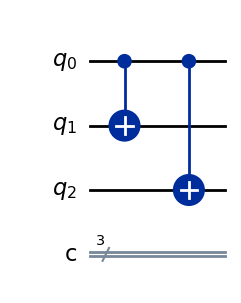

In [2]:

from qiskit import QuantumCircuit
from qiskit.quantum_info import StabilizerState, Pauli
 
# 3 Qubit Bit flip encoding
qc = QuantumCircuit(3,3)
qc.cx(0, 1)
qc.cx(0, 2)
qc.draw('mpl')
 

In [3]:
stab = StabilizerState(qc)

# Print the StabilizerState
print(stab)

# Calculate the StabilizerState measurement probabilities dictionary
print (stab.probabilities_dict())

# Calculate expectation value of the StabilizerState
print (stab.expectation_value(Pauli('ZZI')))

StabilizerState(['+IIZ', '+IZZ', '+ZIZ'])
{'000': 1.0}
1


In [4]:
from qiskit.quantum_info import Clifford

qce = QuantumCircuit(2,2)
qce.cx(0,1)
qce.x(0)
qce.z(1)
qce.cx(0,1)
cl = Clifford(qce)
new_circ = cl.to_circuit()

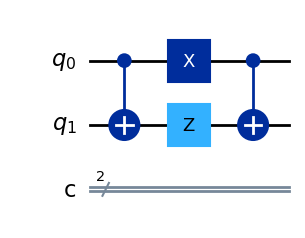

In [6]:
qce.draw('mpl')

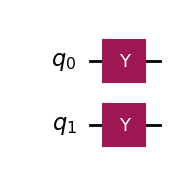

In [5]:
new_circ.draw('mpl')


In [7]:
cl.tableau

array([[ True, False, False, False,  True],
       [False,  True, False, False,  True],
       [False, False,  True, False,  True],
       [False, False, False,  True,  True]])

In [8]:
cl.to_dict()

{'stabilizer': ['-IZ', '-ZI'], 'destabilizer': ['-IX', '-XI']}

# References
1. [Surviving as a Quantum Computer in a Classical World](https://www.cs.umd.edu/~dgottesm/QECCbook-2024.pdf) by Daniel Gottesman
2. D. Gottesman, talk at International Conference on Group Theoretic Methods in Physics (1998)-[The Heisenberg Representation of Quantum Computers by Daniel Gottesman](https://arxiv.org/pdf/quant-ph/9807006)
3. Efficient Simulation of Clifford Circuits by Utkarsh Azad [Pennylane](https://pennylane.ai/qml/demos/tutorial_clifford_circuit_simulations)
4. Improved Simulation of Stabilizer Circuits by Scott Aaronson, Daniel Gottesman[(CHP Simulator)](https://arxiv.org/pdf/quant-ph/0406196) 